В данной работе проводится обработка результатов расчета напряженно-деформированного состояния (НДС) тонкостенного трубчатого образца при сложном нагружении по винтовой траектории.

**Материал:** Сталь 45 (Модель билинейного изотропного упрочнения - **BISO**).

**Цель:** Анализ векторных и скалярных свойств материала, проверка корректности моделирования в ANSYS.

In [758]:
model_name = "BISO"

nu_path = r"nu.txt"
with open(nu_path, "r") as f:
        nu = float(f.read().strip())
nu

0.299999999999

In [759]:
a_path = r"a.txt"
with open(a_path, "r") as f:
        a = float(f.read().strip())

c_path = r"c.txt"
with open(c_path, "r") as f:
        c = float(f.read().strip())

n_turns_path = r"n_turns.txt"
with open(n_turns_path, "r") as f:
        n_turns = float(f.read().strip())

a, c, n_turns

(0.0157, 0.0025, 1.65)

In [760]:
from core.reader import read_ansys_csv

numerical_experiment_data_biso = r"biso.csv"
numerical_experiment_biso = read_ansys_csv(numerical_experiment_data_biso)

### 1. Первичный обзор данных
Проверим структуру загруженного DataFrame. Данные содержат временные метки, компоненты тензоров деформаций (упругих `EPEL`, пластических `EPPL`, полных `EPTO`), напряжений (`S`), а также интенсивность деформаций и параметр Одквиста.

In [761]:
numerical_experiment_biso.sample(3, random_state=42)

,Time,EPEL_TT,EPPL_TT,EPTO_TT,EPEL_ZZ,EPPL_ZZ,EPTO_ZZ,EPEL_TZ,EPPL_TZ,EPTO_TZ,EPEL_RR,EPPL_RR,EPTO_RR,S_TT,S_ZZ,S_TZ,S_EQV,EPPL_EQV,NL_EPEQ
3207,213.7178,0.002008,0.001316,0.003324,-0.000117,0.006072,0.005955,-0.001579,-0.002423,-0.004002,-0.000810,-0.007388,-0.008198,444.4359,109.34760,-124.52260,455.4116,0.008005,0.009076
5890,392.5178,0.002182,0.006873,0.009055,-0.000609,0.003124,0.002515,0.001921,-0.002392,-0.000471,-0.000674,-0.009997,-0.010671,450.4319,10.33715,151.49920,516.9097,0.010321,0.014926
8814,587.4178,0.001617,0.010150,0.011767,0.002151,0.003685,0.005836,0.001054,0.003027,0.004081,-0.001615,-0.013835,-0.015450,509.5787,593.81090,83.09042,574.8047,0.014436,0.020433


### 2. Графики полных деформаций
Построим графики изменения компонент тензора полных деформаций от времени.
* `EPTO_ZZ` — осевая деформация ($\varepsilon_z$).
* `EPTO_TT` — окружная деформация ($\varepsilon_\theta$).
* `EPTO_TZ` — деформация сдвига ($\varepsilon_{\theta z}$).

На первом этапе (растяжение) должна меняться только $\varepsilon_z$. На втором этапе (винт) должны меняться все компоненты.

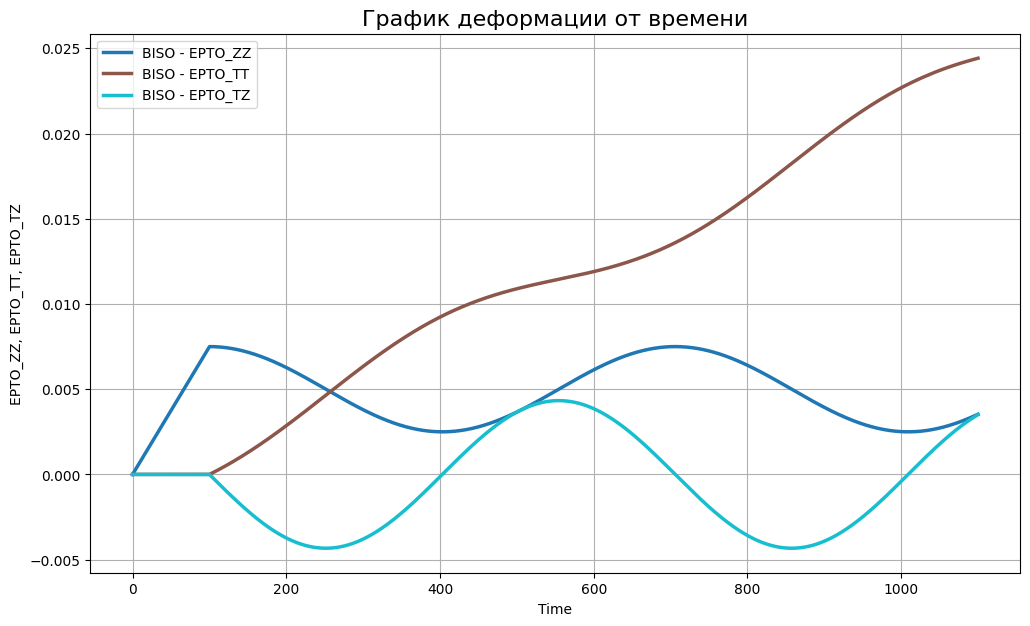

In [762]:
from core.visualizer import plot_xy

plot_xy([
        (model_name, numerical_experiment_biso)
    ],
    "Time",
    ["EPTO_ZZ", "EPTO_TT", "EPTO_TZ"],
    f"График деформации от времени",
    figsize=(12, 7)
)


### 3. Расчет вектора деформаций Ильюшина
Для анализа сложных процессов деформирования перейдем от тензорного представления к векторному в пятимерном евклидовом пространстве А.А. Ильюшина $E^5$.

Компоненты вектора деформаций $\bar{\ni}$ линейно выражаются через компоненты тензора деформаций. Для случая тонкостенного трубчатого образца (где $\varepsilon_{11} = \varepsilon_z$ — осевая, $\varepsilon_{22} = \varepsilon_\theta$ — окружная, $\varepsilon_{12} = \varepsilon_{\theta z}$ — сдвиговая) формулы принимают вид:

$$ \ni_1 = \varepsilon_z - \varepsilon_{mean}$$
$$ \ni_2 = \frac{1}{\sqrt{3}} ((\varepsilon_z - \varepsilon_{mean}) + 2(\varepsilon_\theta - \varepsilon_{mean})) $$
$$ \ni_3 = \frac{2}{\sqrt{3}} \varepsilon_{\theta z} $$

Это позволяет нам анализировать траекторию деформирования как кривую в векторном пространстве, вычислять ее кривизну и угол сближения.

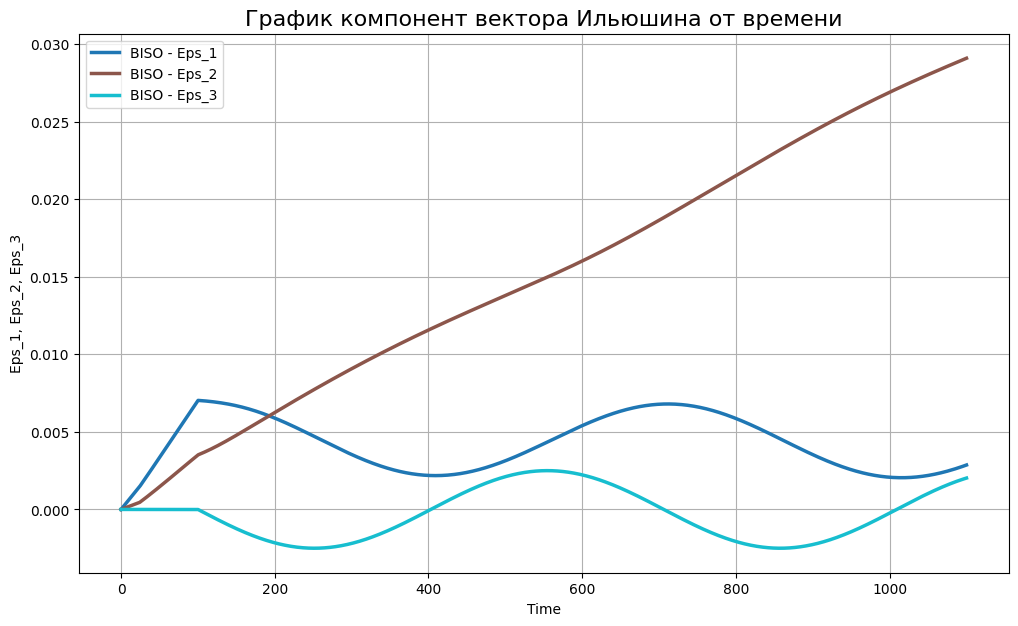

In [763]:
from core.calculations import calculate_ilushin_strain_vector


numerical_experiment_biso_strain_vector = calculate_ilushin_strain_vector(
    numerical_experiment_biso,
    compressible = abs(nu - 0.5) >= 1e-6
)

plot_xy([
        (model_name, numerical_experiment_biso_strain_vector)
    ],
    "Time",
    ["Eps_1", "Eps_2", "Eps_3"],
    f"График компонент вектора Ильюшина от времени",
    figsize=(12, 7)
)

### 4. Разделение этапов деформирования
Процесс нагружения состоит из двух этапов:
1.  **Одноосное растяжение** (прямолинейный участок траектории).
2.  **Сложное нагружение** (винтовая траектория).

Нам необходимо выделить данные, относящиеся только ко второму этапу, так как именно на нем исследуются эффекты сложного деформирования (кручение, кривизна траектории). Момент окончания первого этапа считываем из файла конфигурации `steps_n1.txt`.

In [764]:
step_n1_path = r"steps_n1.txt"
with open(step_n1_path, "r") as f:
        split_time = float(f.read().strip())
split_time

100.0

In [765]:
df_stage2 = numerical_experiment_biso_strain_vector[
    numerical_experiment_biso_strain_vector["Time"] > split_time
].copy()

df_stage2.reset_index(drop=True, inplace=True)
df_stage2["Time_Local"] = df_stage2["Time"] - split_time

In [766]:
df_stage2[:5]

,Time,Eps_1,Eps_2,Eps_3,Time_Local
0,100.0100,0.007028,0.003513,-2.591768e-07,0.0100
1,100.0200,0.007028,0.003513,-5.183535e-07,0.0200
2,100.0350,0.007028,0.003513,-9.071189e-07,0.0350
3,100.0575,0.007028,0.003514,-1.490266e-06,0.0575
4,100.0913,0.007028,0.003514,-2.364988e-06,0.0913


In [767]:
filename = 'df_stage2_biso.pkl'
df_stage2.to_pickle(filename)

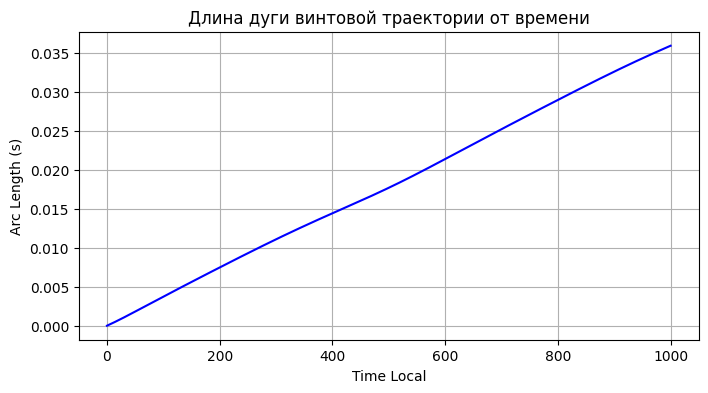

In [768]:
import numpy as np
import matplotlib.pyplot as plt

d_eps = df_stage2[['Eps_1', 'Eps_2', 'Eps_3']].diff().fillna(0)
step_length = np.sqrt(d_eps['Eps_1']**2 + d_eps['Eps_2']**2 + d_eps['Eps_3']**2)
df_stage2['s'] = step_length.cumsum()

plt.figure(figsize=(8, 4))
plt.plot(df_stage2['Time_Local'], df_stage2['s'], 'b-')
plt.xlabel('Time Local')
plt.ylabel('Arc Length (s)')
plt.title('Длина дуги винтовой траектории от времени')
plt.grid(True)
plt.show()

### 5. Аналитическое решение

Для сравнения используется аналитическое решение для **идеально несжимаемого материала** ($\nu=0.5$). В этом случае траектория в пространстве деформаций является идеальной винтовой линией.

Параметризация выполняется по **длине дуги** $s$.
Связь угла поворота $\alpha$ и пути $s$ задается через пространственную частоту $\lambda$:
$$ \alpha(s) = \lambda \cdot s, \quad \text{где } \lambda = \frac{2\pi}{\sqrt{a^2 + (2\pi c)^2}} $$

Производные вычисляются по параметру $s$: $\frac{d\bar{\ni}}{ds}, \frac{d^2\bar{\ni}}{ds^2}, \frac{d^3\bar{\ni}}{ds^3}$.

---

**1. Уравнения траектории (зависимость от $\alpha$):**
В предположении несжимаемости ($\varepsilon_{mean}=0$) компоненты деформаций описываются кинематическими соотношениями:
$$ \varepsilon_z(\alpha) = c \cdot (\cos\alpha - 1) $$
$$ \varepsilon_\theta(\alpha) = \frac{\sqrt{3} a \alpha}{4\pi} - \frac{1}{2} c \cdot (\cos\alpha - 1) $$
$$ \varepsilon_{\theta z}(\alpha) = -\frac{\sqrt{3}}{2} c \cdot \sin\alpha $$

**2. Вектор Ильюшина (переход к базису $\ni_i$):**
Подставляя уравнения траектории в формулы преобразования к векторному пространству для несжимаемого материала:

$$ \ni_1(\alpha) = \varepsilon_z = c(\cos\alpha - 1) $$
$$ \ni_2(\alpha) = \frac{1}{\sqrt{3}}(\varepsilon_z + 2\varepsilon_\theta) = \frac{a \alpha}{2\pi} $$
$$ \ni_3(\alpha) = \frac{2}{\sqrt{3}}\varepsilon_{\theta z} = -c \sin\alpha $$

**3. Производные по длине дуги $s$:**
Используя цепное правило дифференцирования $\frac{d}{ds} = \frac{d}{d\alpha} \frac{d\alpha}{ds} = \lambda \frac{d}{d\alpha}$, получаем:

*   **Первая производная (Скорость, $\mathbf{v}$):**
    $$ \ni_1' = -c \lambda \sin(\lambda s) $$
    $$ \ni_2' = \frac{a \lambda}{2\pi} = \text{const} $$
    $$ \ni_3' = -c \lambda \cos(\lambda s) $$

*   **Вторая производная (Кривизна/Ускорение, $\mathbf{a}$):**
    $$ \ni_1'' = -c \lambda^2 \cos(\lambda s) $$
    $$ \ni_2'' = 0 $$
    $$ \ni_3'' = c \lambda^2 \sin(\lambda s) $$

*   **Третья производная (Рывок, $\mathbf{j}$):**
    $$ \ni_1''' = c \lambda^3 \sin(\lambda s) $$
    $$ \ni_2''' = 0 $$
    $$ \ni_3''' = c \lambda^3 \cos(\lambda s) $$

Эти формулы используются для аналитического расчета кривизны $\varkappa$ и кручения $\tau$. Из равенства нулю второй и третьей производной для компоненты $\ni_2$ следует, что для идеальной траектории геометрические характеристики должны быть **константами**.

In [769]:
step_n2_path = r"steps_n2.txt"
with open(step_n2_path, "r") as f:
        steps_n2 = float(f.read().strip())
steps_n2

1000.0

In [770]:
from core.derivatives.analytical import AnalyticalDerivatives

analytical = AnalyticalDerivatives(c=c, a=a) 

s_vals = df_stage2["s"].values

start_row = numerical_experiment_biso[numerical_experiment_biso["Time"] <= split_time].iloc[-1]
eps_z_start = start_row["EPTO_ZZ"]
eps_theta_start = start_row["EPTO_TT"]

E1, E2, E3 = analytical.get_values(s_vals, eps_z_start, eps_theta_start)
df_stage2["Eps_1_analytic"] = E1
df_stage2["Eps_2_analytic"] = E2
df_stage2["Eps_3_analytic"] = E3

dE, d2E, d3E = analytical.get_all_derivatives(s_vals)

df_stage2["dEps_1_analytic"] = dE[0]
df_stage2["dEps_2_analytic"] = dE[1]
df_stage2["dEps_3_analytic"] = dE[2]

df_stage2["d2Eps_1_analytic"] = d2E[0]
df_stage2["d2Eps_2_analytic"] = d2E[1]
df_stage2["d2Eps_3_analytic"] = d2E[2]

df_stage2["d3Eps_1_analytic"] = d3E[0]
df_stage2["d3Eps_2_analytic"] = d3E[1]
df_stage2["d3Eps_3_analytic"] = d3E[2]

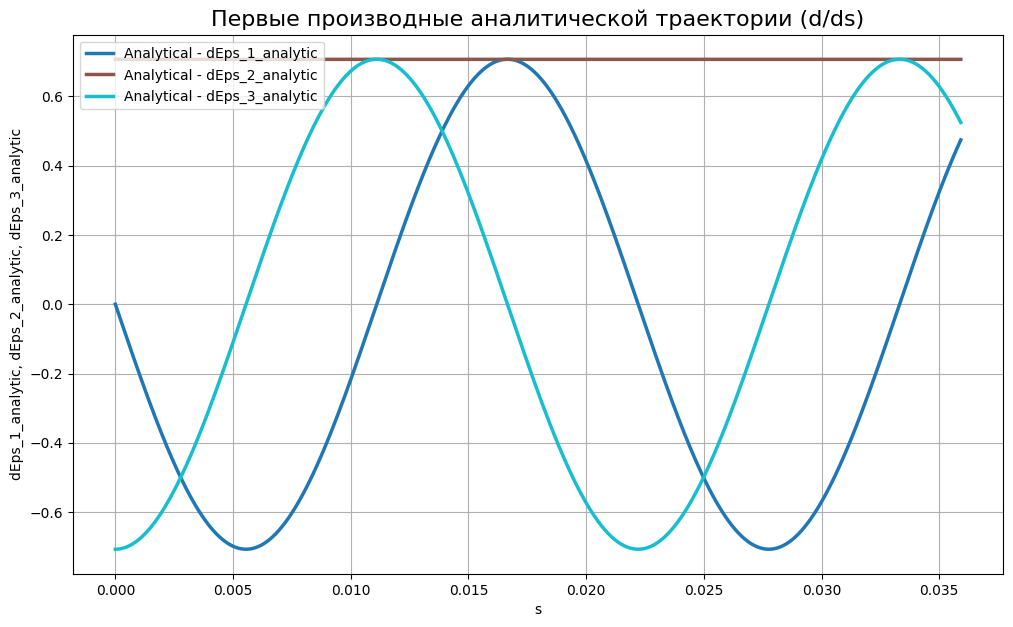

In [771]:
plot_xy(
    [("Analytical", df_stage2)],
    "s",
    ["dEps_1_analytic", "dEps_2_analytic", "dEps_3_analytic"],
    "Первые производные аналитической траектории (d/ds)",
    figsize=(12, 7)
)

На основе проведенного анализа (Grid Search) были определены оптимальные значения гиперпараметров сплайна ($s_{opt}, k_{opt}$), обеспечивающие наилучший баланс между точностью аппроксимации и гладкостью высших производных.

In [772]:
best_s, best_k = 4.7508101621027935e-12, 4

Предполагая, что погрешности решателя ANSYS одинаковы для всех компонент деформаций, мы применяем найденные параметры для дифференцирования **всех компонент** вектора Ильюшина ($\ni_1, \ni_2, \ni_3$).

В результате для каждой компоненты вычисляются и сохраняются в DataFrame:
1.  **Скорость** ($\dot{\ni}$) — префикс `d`
2.  **Ускорение** ($\ddot{\ni}$) — префикс `d2`
3.  **Рывок** ($\dddot{\ni}$) — префикс `d3` (необходим для расчета кручения $\tau$)

In [773]:
from core.derivatives.spline import compute_spline_derivatives


components = ["Eps_1", "Eps_2", "Eps_3"]
for col in components:
    d1, d2, d3 = compute_spline_derivatives(
        df_stage2, 
        col_name=col, 
        time_col="s", 
        s=best_s, 
        k=best_k
    )

    # Названия колонок: dEps_1_spline, d2Eps_1_spline, d3Eps_1_spline
    df_stage2[f"d{col}_spline"] = d1
    df_stage2[f"d2{col}_spline"] = d2
    df_stage2[f"d3{col}_spline"] = d3

Ниже представлены графики изменения компонент вектора деформаций $\ni_1$ и $\ni_3$, а также их вычисленных производных: скорости ($\dot{\ni}$), ускорения ($\ddot{\ni}$) и рывка ($\dddot{\ni}$).

*   **Компонента $\ni_1$** (соответствует осевой деформации $\varepsilon_z$) — отражает процесс растяжения/сжатия в ходе движения по винтовой траектории.
*   **Компонента $\ni_3$** (соответствует сдвигу $\varepsilon_{\theta z}$) — отражает процесс чистого кручения.

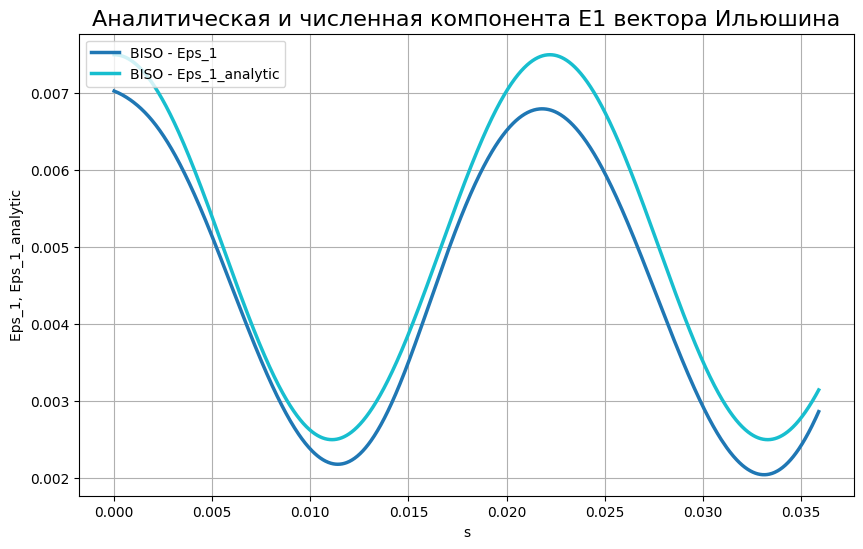

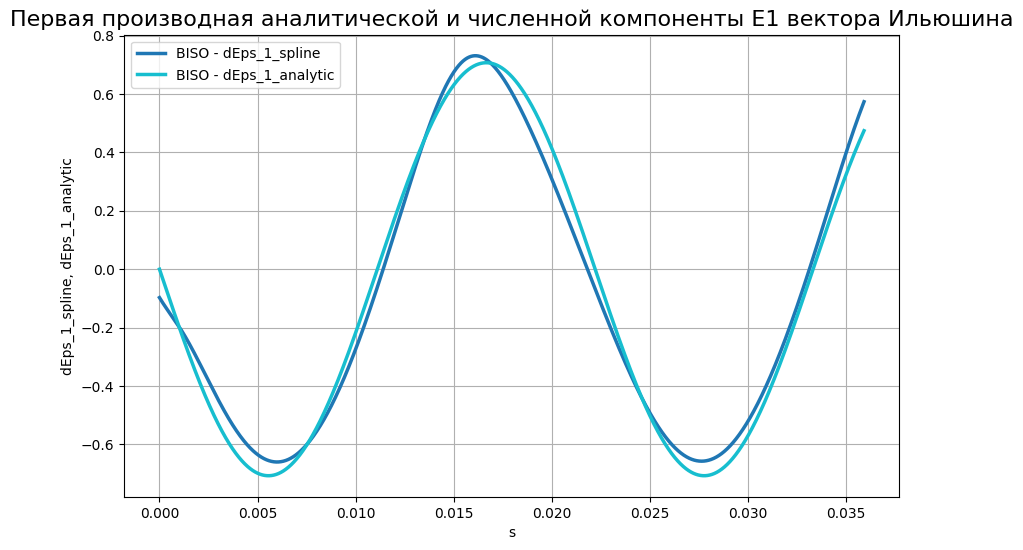

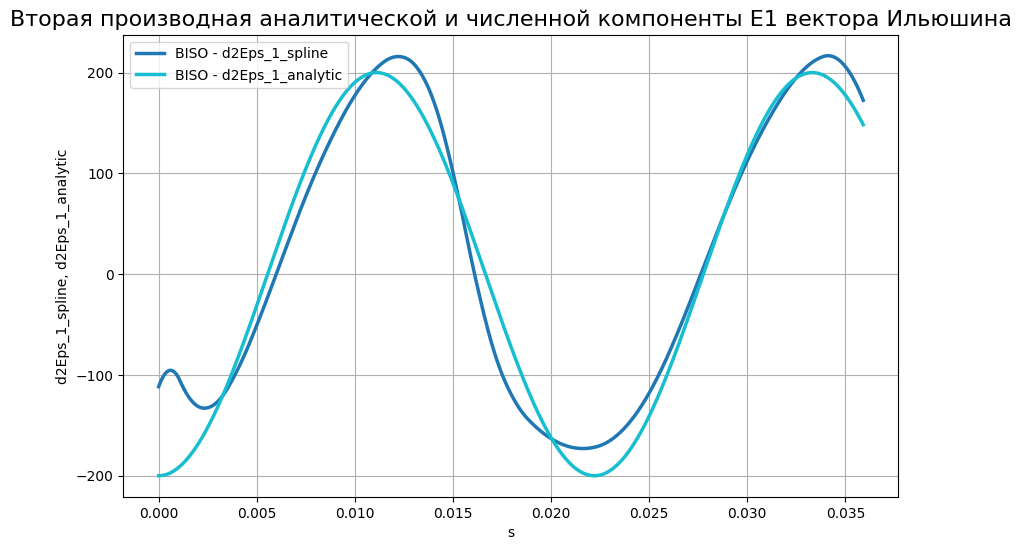

In [774]:
plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col="s",
    y_cols=["Eps_1", "Eps_1_analytic"],
    title="Аналитическая и численная компонента E1 вектора Ильюшина",
    figsize=(10, 6)
)
plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col="s",
    y_cols=["dEps_1_spline", "dEps_1_analytic"],
    title="Первая производная аналитической и численной компоненты E1 вектора Ильюшина",
    figsize=(10, 6)
)
plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col="s",
    y_cols=["d2Eps_1_spline", "d2Eps_1_analytic"],
    title="Вторая производная аналитической и численной компоненты E1 вектора Ильюшина",
    figsize=(10, 6)
)

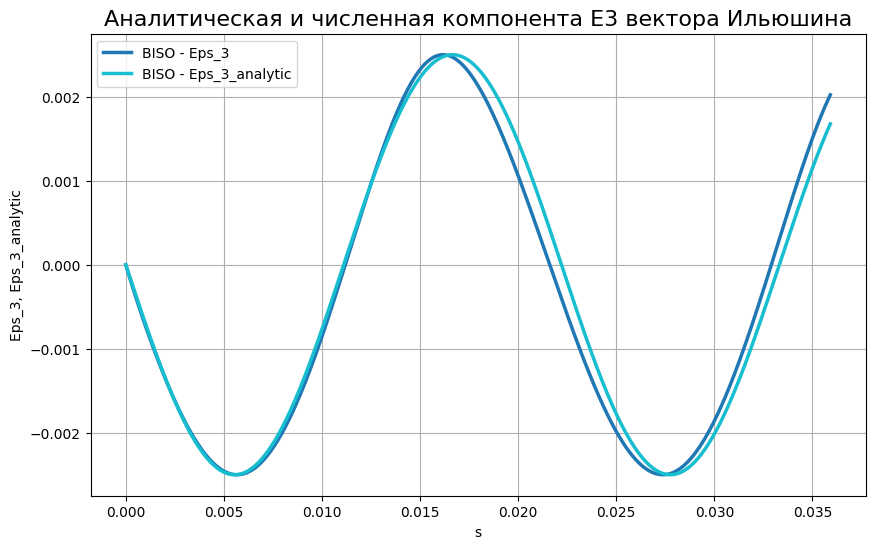

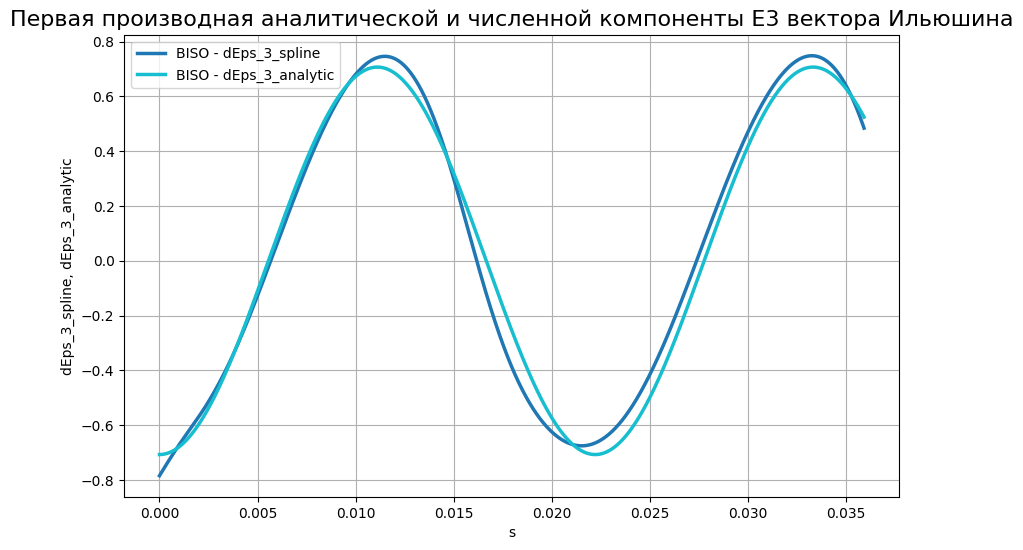

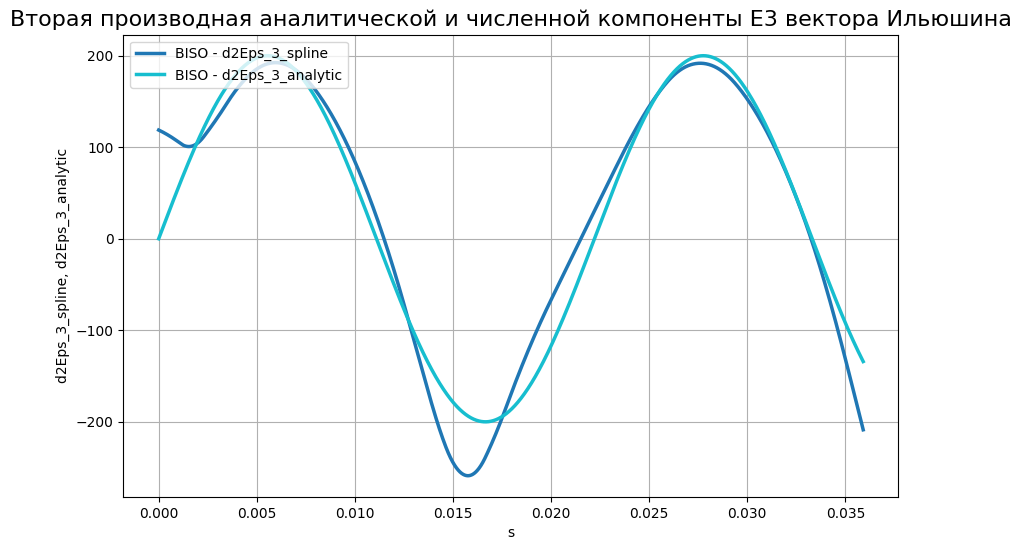

In [775]:
plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col="s",
    y_cols=["Eps_3",
            "Eps_3_analytic",
        ],
    title="Аналитическая и численная компонента E3 вектора Ильюшина",
    figsize=(10, 6)
)
plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col="s",
    y_cols=["dEps_3_spline",
            "dEps_3_analytic",
        ],
    title="Первая производная аналитической и численной компоненты E3 вектора Ильюшина",
    figsize=(10, 6)
)
plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col="s",
    y_cols=["d2Eps_3_spline",
            "d2Eps_3_analytic",
        ],
    title="Вторая производная аналитической и численной компоненты E3 вектора Ильюшина",
    figsize=(10, 6)
)

### 6. Расчет геометрических характеристик траектории

Используя вычисленные производные (скорость $\dot{\bar{\ni}}$, ускорение $\ddot{\bar{\ni}}$, рывок $\dddot{\bar{\ni}}$), мы определяем внутреннюю геометрию траектории деформирования в векторном пространстве.

**Вычисляемые параметры:**

1.  **Длина дуги траектории деформаций $s$:**
    Натуральный параметр процесса, характеризующий накопленную деформацию.
    $$ s(t) = \int_0^t |\dot{\bar{\ni}}(\tau)| d\tau $$

2.  **Кривизна $\varkappa$ (Curvature):**
    Характеризует отклонение траектории от прямой линии.
    $$ \varkappa = \frac{|\dot{\bar{\ni}} \times \ddot{\bar{\ni}}|}{|\dot{\bar{\ni}}|^3} $$

3.  **Кручение $\tau$ (Torsion):**
    Характеризует выход траектории из плоскости соприкасания (отклонение от плоской кривой).
    $$ \tau = \frac{(\dot{\bar{\ni}} \times \ddot{\bar{\ni}}) \cdot \dddot{\bar{\ni}}}{|\dot{\bar{\ni}} \times \ddot{\bar{\ni}}|^2} $$

Расчет производится параллельно для двух наборов данных:
*   **Analytic:** На основе точных формул.
*   **Spline:** На основе численного дифференцирования данных ANSYS.

In [776]:
import numpy as np
from core.calculations import calculate_geometry

s_true, k_true, t_true = calculate_geometry(df_stage2, suffix="_analytic", time_col="s")

df_stage2["s_analytic"] = s_true
df_stage2["kappa_analytic"] = k_true
df_stage2["tau_analytic"] = np.round(np.abs(t_true), decimals=7)

s_spline, k_spline, t_spline = calculate_geometry(df_stage2, suffix="_spline", time_col="s")

df_stage2["s_spline"] = s_spline
df_stage2["kappa_spline"] = k_spline
df_stage2["tau_spline"] = np.abs(t_spline)

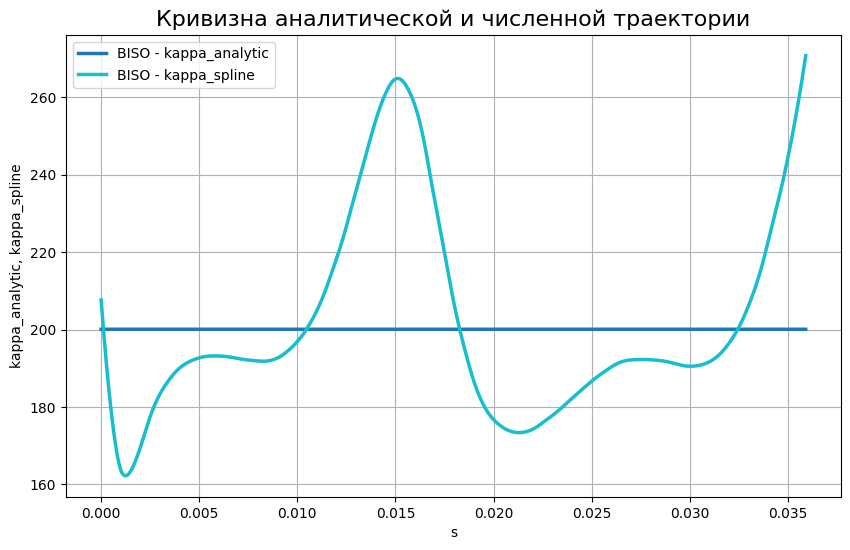

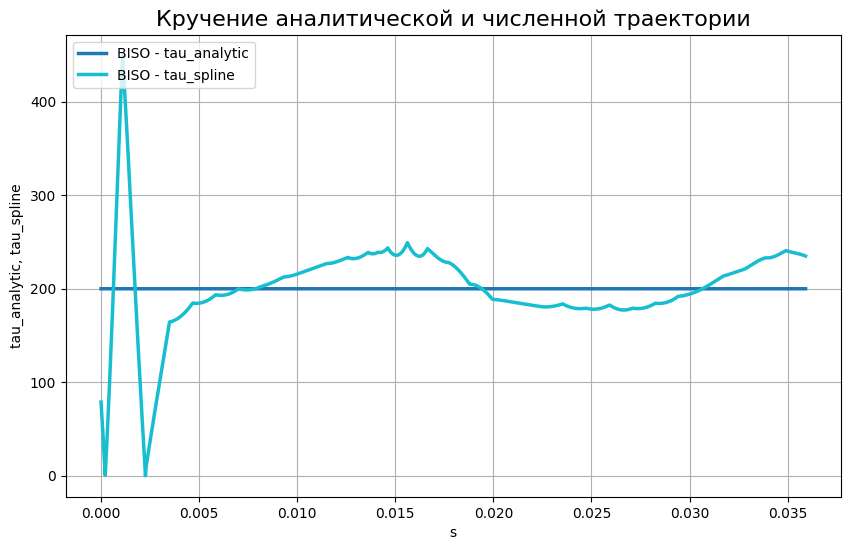

In [777]:
plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col="s",
    y_cols=["kappa_analytic", "kappa_spline"],
    title="Кривизна аналитической и численной траектории",
    figsize=(10, 6)
)

plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col="s",
    y_cols=["tau_analytic", "tau_spline"],
    title="Кручение аналитической и численной траектории",
    figsize=(10, 6)
)

### 7. Векторные свойства материала: Расчет угла сближения

Для анализа векторных свойств материала (отклонения поведения от теории малых упруго-пластических деформаций) необходимо сопоставить направление вектора напряжений $\bar{\sigma}$ с направлением мгновенной скорости деформации $\dot{\bar{\ni}}$ (касательной к траектории).

**1. Построение вектора напряжений $\bar{\sigma}$**
Вектор напряжений в пространстве Ильюшина строится на основе компонент **девиатора напряжений** $S_{ij}$. Результаты ANSYS (для элемента PLANE182) содержат компоненты тензора напряжений: $\sigma_z$ (осевое), $\sigma_\theta$ (окружное) и $\tau_{z\theta}$ (касательное).

Сначала вычисляются компоненты девиатора:
$$ S_{zz} = \sigma_z - \sigma_{mean}, \quad S_{\theta\theta} = \sigma_\theta - \sigma_{mean}, \quad S_{z\theta} = \tau_{z\theta} $$
где $\sigma_{mean} = \frac{1}{3}(\sigma_z + \sigma_\theta)$.

Компоненты вектора $\bar{\sigma}$ определяются линейным преобразованием:
$$ \sigma_1 = \frac{3}{2} S_{zz} $$
$$ \sigma_2 = \frac{\sqrt{3}}{2} (S_{zz} + 2S_{\theta\theta}) $$
$$ \sigma_3 = \sqrt{3} S_{z\theta} $$

**2. Расчет угла сближения $\vartheta_1$**
Угол сближения (или угол запаздывания) $\vartheta_1$ — это угол между вектором напряжений $\bar{\sigma}$ и вектором скорости деформаций $\dot{\bar{\ni}}$ в пятимерном пространстве. Он вычисляется через скалярное произведение:

$$ \cos \vartheta_1 = \frac{\bar{\sigma} \cdot \dot{\bar{\ni}}}{|\bar{\sigma}| \cdot |\dot{\bar{\ni}}|} $$

Этот параметр характеризует степень неколлинеарности тензоров напряжений и скоростей деформаций, возникающую вследствие сложного нагружения.

In [778]:
df_stress_stage2 = numerical_experiment_biso.loc[
    numerical_experiment_biso["Time"] > split_time, 
    ["S_ZZ", "S_TZ", "S_TT", "Time"]
].copy()

df_stress_stage2.reset_index(drop=True, inplace=True)

df_stress_stage2["Time_Local"] = df_stress_stage2["Time"] - split_time

df_stress_stage2[:5]

,S_ZZ,S_TZ,S_TT,Time,Time_Local
0,489.3058,-0.035393,236.5453,100.0100,0.0100
1,489.3076,-0.070785,236.5923,100.0200,0.0200
2,489.3103,-0.123870,236.6627,100.0350,0.0350
3,489.3143,-0.203491,236.7682,100.0575,0.0575
4,489.3201,-0.322907,236.9265,100.0913,0.0913


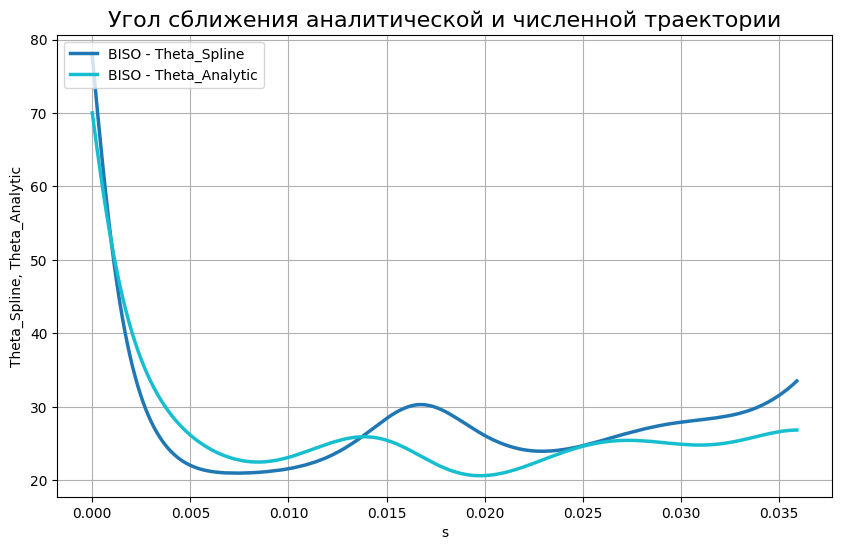

In [779]:
from core.calculations import calculate_stress_vector, calculate_theta


sig_1, sig_2, sig_3 = calculate_stress_vector(df_stress_stage2)
df_stage2["Sig_1"] = sig_1
df_stage2["Sig_2"] = sig_2
df_stage2["Sig_3"] = sig_3

theta_spline = calculate_theta(df_stage2, deriv_suffix="_spline")
df_stage2["Theta_Spline"] = theta_spline

theta_analytic = calculate_theta(df_stage2, deriv_suffix="_analytic")
df_stage2["Theta_Analytic"] = theta_analytic


plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col="s",
    y_cols=["Theta_Spline", "Theta_Analytic"],
    title="Угол сближения аналитической и численной траектории",
    figsize=(10, 6)
)

### 8. Аппроксимация среднего напряжения

Анализ результатов показал, что прямое численное дифференцирование экспериментальных данных (даже с использованием сглаживающих сплайнов) не позволяет получить устойчивые значения высших производных, необходимых для расчета кручения. Сплайны чувствительны к локальному шуму и демонстрируют краевые эффекты.

Учитывая физическую природу процесса (движение по винтовой траектории), изменение объема (и пропорционального ему среднего напряжения) должно носить периодический характер с наложением монотонного тренда. Вместо локального сглаживания мы применяем **глобальную аппроксимацию** зависимости среднего напряжения $\sigma_{mean}$ от длины дуги $s$.

**Модель аппроксимации (`VolumetricModel`):**

Зависимость описывается гармонической функцией с линейным трендом:

$$ \sigma_{mean}(s) \approx p \cdot \cos(\omega \cdot s + \phi) + b_1 \cdot s + b_2 $$

где параметры модели имеют следующий физический смысл:
*   $p$ — **Амплитуда** пульсаций среднего напряжения (вызвана вращением вектора деформаций).
*   $\omega$ — **Пространственная частота** колебаний (связана с геометрией винтовой линии).
*   $\phi$ — **Фазовый сдвиг**.
*   $b_1$ — **Линейный тренд** (накопление гидростатического давления/изменения объема в процессе пластического деформирования).
*   $b_2$ — **Базовое смещение**.

Найденная аналитическая зависимость позволяет вычислить гладкие производные любого порядка для коррекции вектора Ильюшина.

In [780]:
from core.derivatives.stress_approximation import VolumetricModel
import pandas as pd

cols_stress = ['S_ZZ', 'S_TT']
df_stress = numerical_experiment_biso.loc[numerical_experiment_biso['Time'] > split_time, cols_stress].reset_index(drop=True)
df_stage2 = pd.concat([df_stage2, df_stress], axis=1)
df_stage2['Sigma_Mean'] = (df_stage2['S_ZZ'] + df_stage2['S_TT']) / 3.0

vol_model = VolumetricModel()
vol_model.fit(df_stage2['s'].values, df_stage2['Sigma_Mean'].values)

array([1.09933466e+02, 2.86768413e+02, 7.26557948e-01, 3.40008745e+03,
       2.06267259e+02])

Параметры аппроксимации среднего напряжения:
  Амплитуда (p):       109.9335 МПа
  Пространств. частота (w): 286.7684 рад/мм
  Линейный тренд (b1): 3400.0875 МПа/мм
  Смещение (phi): 0.7266 рад
  Базовое смещение (b2): 206.2673 МПа


<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Arina\AppData\Local\Temp\ipykernel_34344\2051867412.py:20: SyntaxWarning: invalid escape sequence '\s'
  plt.title('Аппроксимация среднего напряжения $\sigma_{mean}(s)$', fontsize=14)


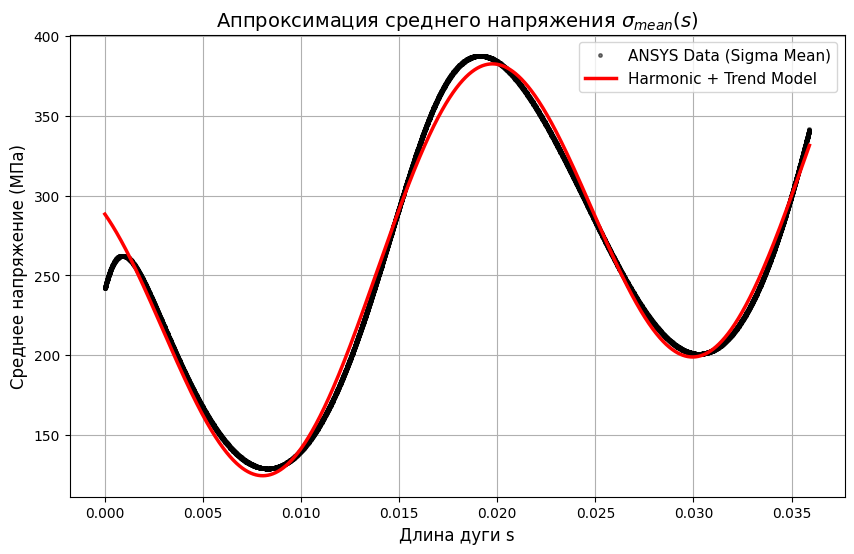

In [781]:
import matplotlib.pyplot as plt

s_vals = df_stage2['s'].values
sigma_real = df_stage2['Sigma_Mean'].values
sigma_approx = vol_model.predict(s_vals)

p, w, phi, b1, b2 = vol_model.params

print(f"Параметры аппроксимации среднего напряжения:")
print(f"  Амплитуда (p):       {p:.4f} МПа")
print(f"  Пространств. частота (w): {w:.4f} рад/мм")
print(f"  Линейный тренд (b1): {b1:.4f} МПа/мм")
print(f"  Смещение (phi): {phi:.4f} рад")
print(f"  Базовое смещение (b2): {b2:.4f} МПа")

plt.figure(figsize=(10, 6))
plt.plot(s_vals, sigma_real, 'k.', markersize=5, alpha=0.5, label='ANSYS Data (Sigma Mean)')
plt.plot(s_vals, sigma_approx, 'r-', linewidth=2.5, label='Harmonic + Trend Model')

plt.title('Аппроксимация среднего напряжения $\sigma_{mean}(s)$', fontsize=14)
plt.xlabel('Длина дуги s', fontsize=12)
plt.ylabel('Среднее напряжение (МПа)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True)
plt.show()

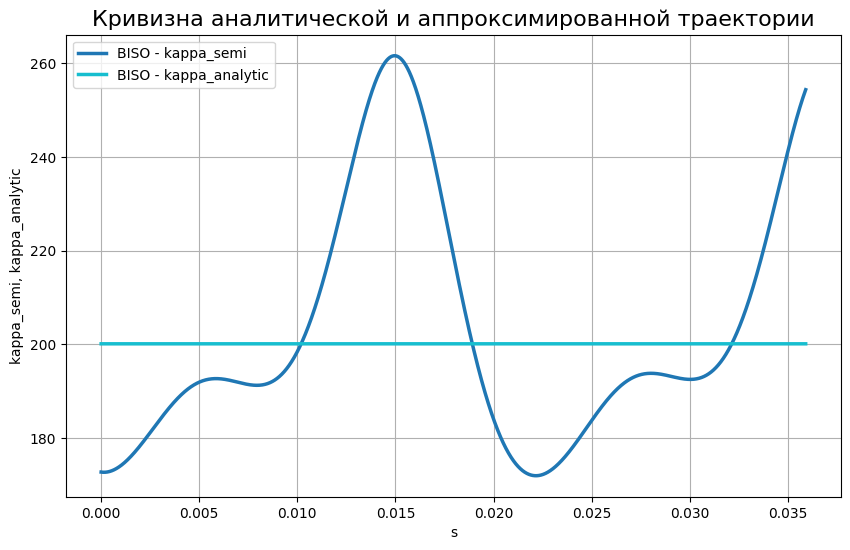

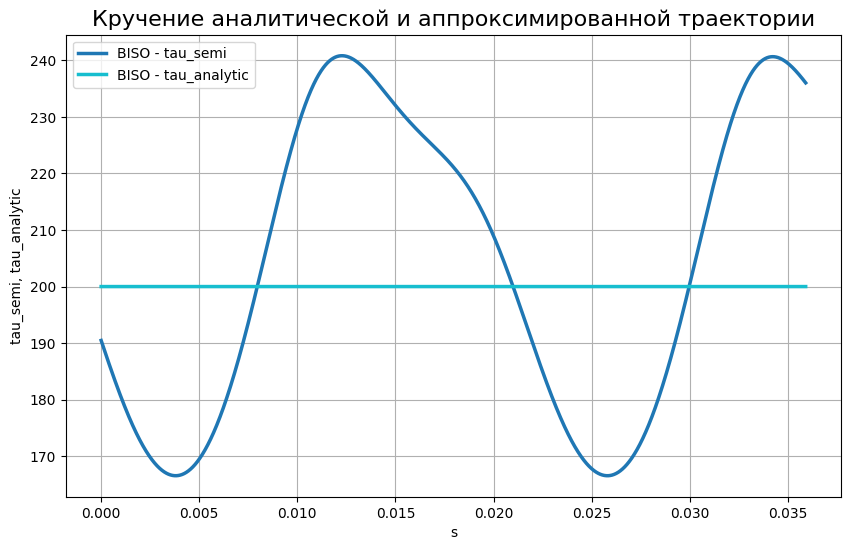

In [782]:
from core.derivatives.stress_approximation import GeometricProperties


approx = GeometricProperties(vol_model, E=2.05e5, nu=nu, c=c, a=a)
k_semi, t_semi = approx.compute_geometry(df_stage2['s'].values)

df_stage2['kappa_semi'] = k_semi
df_stage2['tau_semi'] = np.abs(t_semi)

plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col="s",
    y_cols=["kappa_semi", "kappa_analytic"],
    title="Кривизна аналитической и аппроксимированной траектории",
    figsize=(10, 6)
)

plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col="s",
    y_cols=["tau_semi", "tau_analytic"],
    title="Кручение аналитической и аппроксимированной траектории",
    figsize=(10, 6)
)

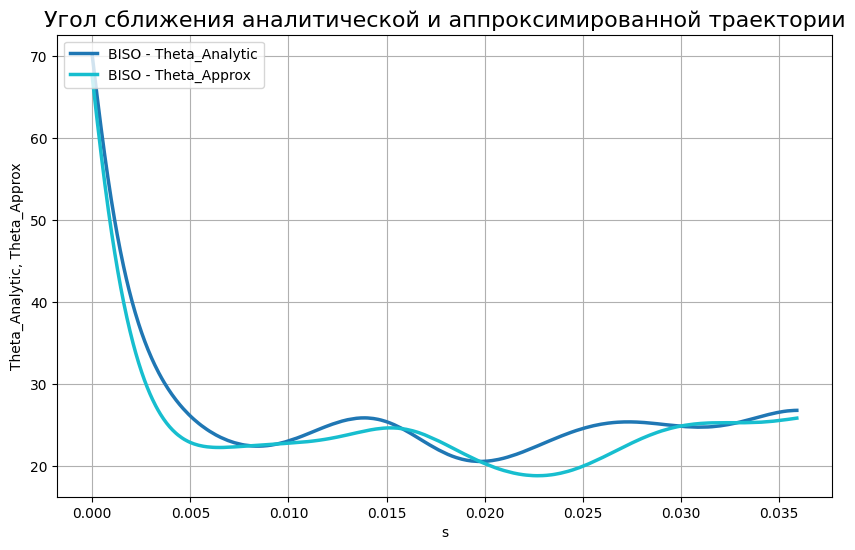

In [783]:
v1, v2, v3 = approx.get_derivatives(df_stage2['s'].values)

df_stage2['dEps_1_approx'] = v1
df_stage2['dEps_2_approx'] = v2
df_stage2['dEps_3_approx'] = v3

theta_semi = calculate_theta(df_stage2, deriv_suffix='_approx')
df_stage2['Theta_Approx'] = theta_semi

plot_xy(
    [(model_name, df_stage2)],
    "s",
    ['Theta_Analytic', 'Theta_Approx'],
    title="Угол сближения аналитической и аппроксимированной траектории",
    figsize=(10, 6)
)

### 9. Сопоставление с экспериментальными данными

Для верификации численной модели используются данные эксперимента из статьи 1986 года. При обработке экспериментальных данных приняты следующие важные допущения:

1. **Условие несжимаемости:** В оригинальном эксперименте деформирование проводилось в предположении идеальной несжимаемости материала ($\nu = 0.5$). В связи с этим радиальная деформация $\varepsilon_{rr}$ не измерялась, а средняя деформация принималась равной нулю ($\varepsilon_{mean} = 0$). В коде это учитывается вызовом функции `calculate_ilushin_strain_vector` с параметром `compressible=False`.
2. **Расчет длины дуги ($s$):** Поскольку экспериментальные данные представлены дискретными точками (замерами), длина дуги рассчитывается как накопленная сумма евклидовых расстояний между последовательными точками в пятимерном пространстве Ильюшина:
$$s_n = \sum_{i=1}^{n} \Delta s_i, \quad \Delta s_i = \sqrt{(\Delta \ni_1)^2 + (\Delta \ni_2)^2 + (\Delta \ni_3)^2}$$
3. **Синхронизация систем координат:** Для соответствия направлению закручивания винта в численной модели (ANSYS), для экспериментальных данных выполнена инверсия знаков сдвиговых компонент ($S_{tz}$ и $\varepsilon_{tz}$).
4. **База сравнения:** Угол сближения $\vartheta_1$ для эксперимента рассчитывается относительно касательной к траектории, полученной из ANSYS (метод `approx.get_derivatives`), что позволяет оценить чистое расхождение векторов напряжений на единой геометрической базе.

In [784]:
from core.reader import load_experimental_data
from core.calculations import calculate_ilushin_strain_vector, calculate_stress_vector, calculate_theta

exp_folder = r"D:\Users\complex_deformations\P29\experimental_vint"
df_exp_raw = load_experimental_data(exp_folder)
df_exp_raw['S_TZ'] = -df_exp_raw['S_TZ']
df_exp_raw['EPTO_TZ'] = -df_exp_raw['EPTO_TZ']

df_exp_illyu = calculate_ilushin_strain_vector(df_exp_raw, compressible=False)
split_time_exp = 14.0
df_exp_vint = df_exp_raw[df_exp_raw['Time'] >= split_time_exp].copy()
df_exp_illyu_vint = df_exp_illyu[df_exp_illyu['Time'] >= split_time_exp].copy()

d_eps_exp = df_exp_illyu_vint[['Eps_1', 'Eps_2', 'Eps_3']].diff().fillna(0)
step_length_exp = np.sqrt(d_eps_exp['Eps_1']**2 + d_eps_exp['Eps_2']**2 + d_eps_exp['Eps_3']**2)
df_exp_vint['s_plot'] = step_length_exp.cumsum()

s1_exp, s2_exp, s3_exp = calculate_stress_vector(df_exp_vint)
df_exp_vint['Sig_1_exp'] = s1_exp
df_exp_vint['Sig_2_exp'] = s2_exp
df_exp_vint['Sig_3_exp'] = s3_exp
df_exp_vint['S_EQV_exp'] = np.sqrt(s1_exp**2 + s2_exp**2 + s3_exp**2)

v_ans_at_exp = approx.get_derivatives(df_exp_vint['s_plot'].values)

df_exp_theta_calc = pd.DataFrame({
    'Sig_1': df_exp_vint['Sig_1_exp'],
    'Sig_2': df_exp_vint['Sig_2_exp'],
    'Sig_3': df_exp_vint['Sig_3_exp'],
    'dEps_1_approx': v_ans_at_exp[0],
    'dEps_2_approx': v_ans_at_exp[1],
    'dEps_3_approx': v_ans_at_exp[2]
})

df_exp_vint['Theta_exp_vs_approx'] = calculate_theta(df_exp_theta_calc, deriv_suffix='_approx')

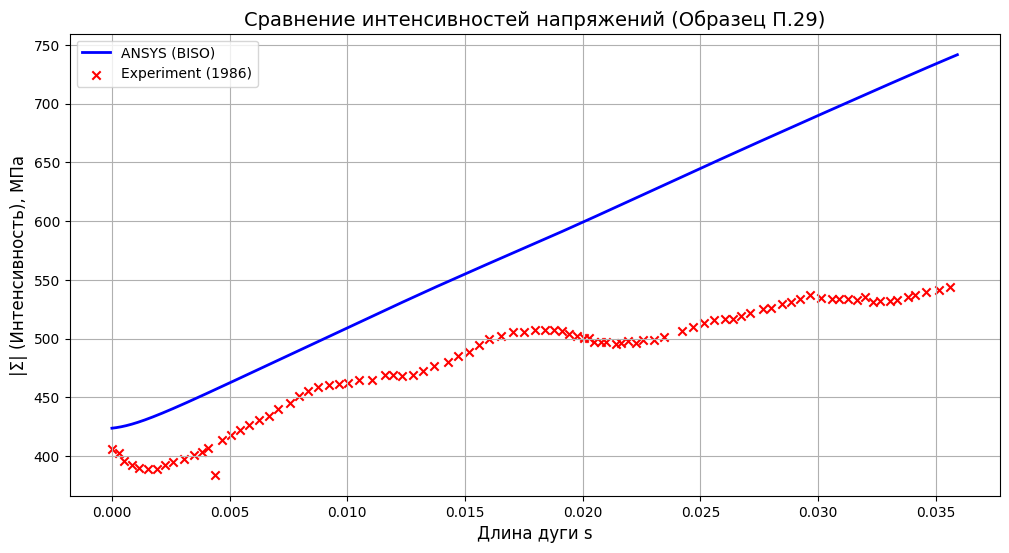

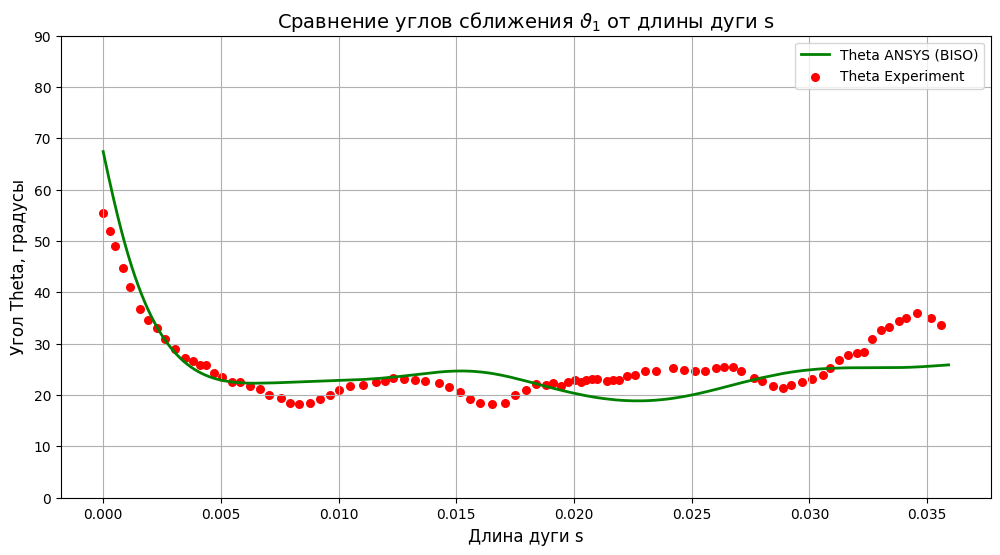

In [785]:
import matplotlib.pyplot as plt

if 'S_EQV' not in df_stage2.columns:
    df_stage2['S_EQV'] = np.sqrt(df_stage2['Sig_1']**2 + df_stage2['Sig_2']**2 + df_stage2['Sig_3']**2)

plt.figure(figsize=(12, 6))
plt.plot(df_stage2['s'], df_stage2['S_EQV'], 'b-', label=f'ANSYS ({model_name})', linewidth=2)
plt.scatter(df_exp_vint['s_plot'], df_exp_vint['S_EQV_exp'], color='red', marker='x', label='Experiment (1986)')
plt.title(f'Сравнение интенсивностей напряжений (Образец П.29)', fontsize=14)
plt.xlabel('Длина дуги s', fontsize=12)
plt.ylabel('|Σ| (Интенсивность), МПа', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df_stage2['s'], df_stage2['Theta_Approx'], 'g-', label=f'Theta ANSYS ({model_name})', linewidth=2)
plt.scatter(df_exp_vint['s_plot'], df_exp_vint['Theta_exp_vs_approx'], color='red', marker='o', s=30, label='Theta Experiment')
plt.title(f'Сравнение углов сближения $\\vartheta_1$ от длины дуги s', fontsize=14)
plt.xlabel('Длина дуги s', fontsize=12)
plt.ylabel('Угол Theta, градусы', fontsize=12)
plt.legend()
plt.grid(True)
plt.ylim(0, 90) 
plt.show()